# NeuroGuide AI — Week 3 Deliverable
## Machine Learning Model: Alzheimer's Educational Risk Prediction

**Author:** Moriah Holland  
**Program:** MSAI 699 Capstone — University of the Cumberlands  
**Date:** 07/2026

---

### Objective

This notebook demonstrates the machine learning component of NeuroGuide AI: a Random Forest classifier that predicts an educational cognitive risk category (Low / Moderate / High) based on demographic, lifestyle, cardiovascular, and genetic (APOE ε4) risk factors.

The model is trained on the **Alzheimer's Prediction Dataset (Global)** (Panday, 2025, Kaggle) — 74,283 records across multiple countries — and evaluated using standard classification metrics and SHAP explainability.

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Data Loading & Exploration

The dataset contains 74,283 records with 25 features covering demographic, lifestyle, cardiovascular, and genetic factors. The target variable is `Alzheimer's Diagnosis` (Yes/No).

In [2]:
# Load the dataset
# Looks for the CSV in the same folder as this notebook first (portable),
# then falls back to the original project path if not found.
import os

CANDIDATE_PATHS = [
    "alzheimers_prediction_dataset.csv",
    "../services/rag-api/data/alzheimers_prediction_dataset.csv",
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find alzheimers_prediction_dataset.csv. "
        "Place it in the same folder as this notebook, or update CANDIDATE_PATHS above."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded data from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")


Loaded data from: alzheimers_prediction_dataset.csv
Dataset shape: (74283, 25)

Columns: ['Country', 'Age', 'Gender', 'Education Level', 'BMI', 'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level', 'Family History of Alzheimer’s', 'Cognitive Test Score', 'Depression Level', 'Sleep Quality', 'Dietary Habits', 'Air Pollution Exposure', 'Employment Status', 'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level', 'Income Level', 'Stress Levels', 'Urban vs Rural Living', 'Alzheimer’s Diagnosis']


In [3]:
# Basic overview
df.head()

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
Country                                 0
Age                                     0
Gender                                  0
Education Level                         0
BMI                                     0
Physical Activity Level                 0
Smoking Status                          0
Alcohol Consumption                     0
Diabetes                                0
Hypertension                            0
Cholesterol Level                       0
Family History of Alzheimer’s           0
Cognitive Test Score                    0
Depression Level                        0
Sleep Quality                           0
Dietary Habits                          0
Air Pollution Exposure                  0
Employment Status                       0
Marital Status                          0
Genetic Risk Factor (APOE-ε4 allele)    0
Social Engagement Level                 0
Income Level                            0
Stress Levels                           0
Urban v

Target distribution:
Alzheimer’s Diagnosis
No     43570
Yes    30713
Name: count, dtype: int64

Diagnosis rate: 41.3%


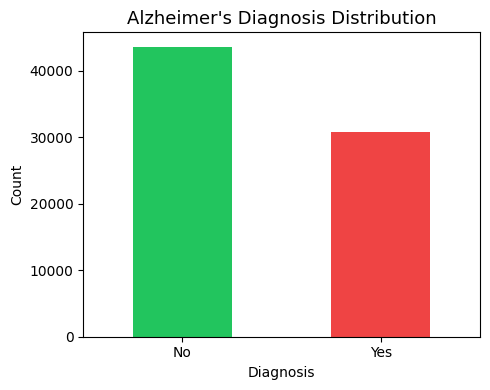

In [5]:
# Target distribution
diag_col = "Alzheimer\u2019s Diagnosis"  # Unicode right single quotation mark
target_counts = df[diag_col].value_counts()
print("Target distribution:")
print(target_counts)
print(f"\nDiagnosis rate: {target_counts['Yes'] / len(df) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', color=['#22c55e', '#ef4444'], ax=ax)
ax.set_title("Alzheimer's Diagnosis Distribution", fontsize=13)
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

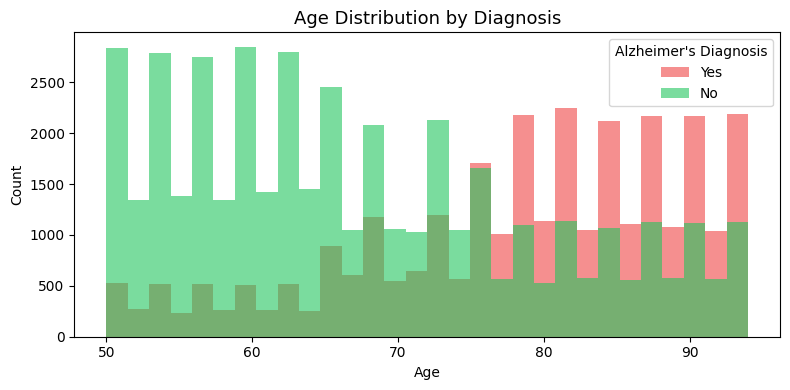

In [6]:
# Age distribution by diagnosis
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("Yes", "#ef4444"), ("No", "#22c55e")]:
    df[df[diag_col] == label]["Age"].plot(
        kind="hist", bins=30, alpha=0.6, color=color, label=label, ax=ax
    )
ax.set_title("Age Distribution by Diagnosis", fontsize=13)
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend(title="Alzheimer's Diagnosis")
plt.tight_layout()
plt.show()

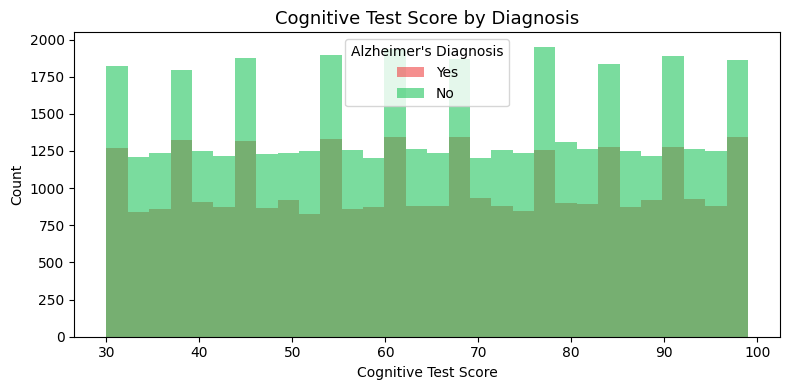

In [7]:
# Cognitive Test Score distribution
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("Yes", "#ef4444"), ("No", "#22c55e")]:
    df[df[diag_col] == label]["Cognitive Test Score"].plot(
        kind="hist", bins=30, alpha=0.6, color=color, label=label, ax=ax
    )
ax.set_title("Cognitive Test Score by Diagnosis", fontsize=13)
ax.set_xlabel("Cognitive Test Score")
ax.set_ylabel("Count")
ax.legend(title="Alzheimer's Diagnosis")
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Preprocessing

The dataset's binary `Alzheimer's Diagnosis` target is extended into a **3-class educational risk label** that better supports the educational goal of NeuroGuide AI:

| Condition | Risk Label |
|-----------|------------|
| Diagnosed = Yes | **High** |
| Diagnosed = No, Cognitive Score < 50 | **Moderate** (at-risk) |
| Diagnosed = No, Cognitive Score ≥ 50 | **Low** |

Features are selected based on the **Lancet Commission on Dementia Prevention (2024)** modifiable risk factors, plus APOE ε4 genetic status.

In [8]:
apoe_col = "Genetic Risk Factor (APOE-\u03b54 allele)"  # ε = U+03B5

# Build feature matrix
X = pd.DataFrame({
    "age":                df["Age"],
    "education_years":    df["Education Level"],
    "apoe4":              (df[apoe_col] == "Yes").astype(int),
    "hypertension":       (df["Hypertension"] == "Yes").astype(int),
    "obesity":            (df["BMI"] >= 30).astype(int),
    "smoking":            df["Smoking Status"].isin(["Current", "Former"]).astype(int),
    "depression":         df["Depression Level"].isin(["Medium", "High"]).astype(int),
    "physical_inactivity":(df["Physical Activity Level"] == "Low").astype(int),
    "diabetes":           (df["Diabetes"] == "Yes").astype(int),
    "social_isolation":   (df["Social Engagement Level"] == "Low").astype(int),
    "excess_alcohol":     (df["Alcohol Consumption"] == "Regularly").astype(int),
    "high_cholesterol":   (df["Cholesterol Level"] == "High").astype(int),
})

FEATURE_LABELS = [
    "Age", "Years of Education", "APOE ε4 Allele",
    "Hypertension", "Obesity (BMI ≥ 30)", "Current/Former Smoker",
    "History of Depression", "Physically Inactive",
    "Type 2 Diabetes", "Social Isolation",
    "Excess Alcohol", "High Cholesterol",
]

# Derive 3-class target
diagnosed = df[diag_col] == "Yes"
low_cog   = df["Cognitive Test Score"] < 50

y = np.where(diagnosed, 2, np.where(low_cog, 1, 0))
RISK_LABELS = ["Low", "Moderate", "High"]

print("Feature matrix shape:", X.shape)
print("\nClass distribution:")
for i, label in enumerate(RISK_LABELS):
    count = (y == i).sum()
    print(f"  {label:10s}: {count:6d} ({count/len(y)*100:.1f}%)")

Feature matrix shape: (74283, 12)

Class distribution:
  Low       :  31307 (42.1%)
  Moderate  :  12263 (16.5%)
  High      :  30713 (41.3%)


In [9]:
# Train / test split — stratified to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

Training set: 59,426 samples
Test set:     14,857 samples


---
## 4. Model Selection Rationale

**Why Random Forest?**

| Criterion | Rationale |
|-----------|----------|
| **Tabular data** | RF is the standard, well-validated choice for structured tabular clinical risk factors |
| **Mixed feature types** | Handles numeric (age, education) and binary (lifestyle flags) without scaling |
| **Explainability** | Supports exact SHAP TreeExplainer attributions — critical for a transparent health-education tool |
| **Small-to-medium dataset** | Outperforms deep networks on datasets of this size without needing large training corpora |
| **Calibrated probabilities** | Probability outputs (Low/Moderate/High) are more interpretable than a single prediction |

A neural network would require far more training data and provides approximate (not exact) SHAP values, making it a weaker choice for this explainability-focused use case.

---
## 5. Model Training

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,       # 200 trees for stable predictions
    max_depth=8,            # Limit depth to reduce overfitting
    min_samples_leaf=10,    # Smooth probability estimates
    class_weight="balanced",# Compensate for class imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,              # Use all CPU cores
)

rf.fit(X_train, y_train)
print("Model training complete.")
print(f"  Estimators: {rf.n_estimators}")
print(f"  Max depth:  {rf.max_depth}")
print(f"  Features:   {rf.n_features_in_}")

Model training complete.
  Estimators: 200
  Max depth:  8
  Features:   12


---
## 6. Baseline Performance Evaluation

In [11]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec  = recall_score(y_test, y_pred, average="weighted")
f1   = f1_score(y_test, y_pred, average="weighted")

# Multi-class ROC-AUC (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted")

print("=" * 40)
print("  BASELINE PERFORMANCE METRICS")
print("=" * 40)
print(f"  Accuracy:          {acc:.4f}")
print(f"  Precision (wtd):   {prec:.4f}")
print(f"  Recall    (wtd):   {rec:.4f}")
print(f"  F1 Score  (wtd):   {f1:.4f}")
print(f"  ROC-AUC   (OvR):   {roc_auc:.4f}")
print("=" * 40)

  BASELINE PERFORMANCE METRICS
  Accuracy:          0.5157
  Precision (wtd):   0.5437
  Recall    (wtd):   0.5157
  F1 Score  (wtd):   0.5186
  ROC-AUC   (OvR):   0.7180


In [12]:
# Per-class classification report
print(classification_report(y_test, y_pred, target_names=RISK_LABELS))

              precision    recall  f1-score   support

         Low       0.57      0.38      0.45      6261
    Moderate       0.22      0.34      0.27      2453
        High       0.65      0.72      0.68      6143

    accuracy                           0.52     14857
   macro avg       0.48      0.48      0.47     14857
weighted avg       0.54      0.52      0.52     14857



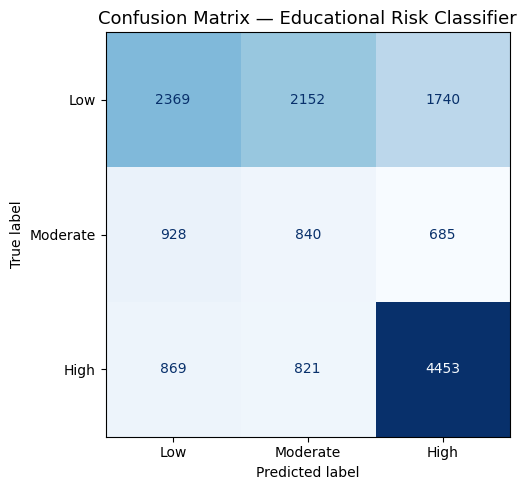

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_LABELS)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Educational Risk Classifier", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# 5-fold cross-validation F1 (weighted) for robustness check
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="f1_weighted", n_jobs=-1)
print(f"5-fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores: {[round(s, 4) for s in cv_scores]}")

5-fold CV F1 (weighted): 0.5247 ± 0.0062
Per-fold scores: [np.float64(0.5284), np.float64(0.521), np.float64(0.5341), np.float64(0.5241), np.float64(0.5158)]


---
## 7. Explainability — SHAP Feature Attributions

SHAP (SHapley Additive exPlanations) with `TreeExplainer` computes exact feature attributions for every prediction. This is the XAI layer exposed in the NeuroGuide AI risk panel.

In [15]:
# Compute SHAP values on a sample for speed
explainer   = shap.TreeExplainer(rf)
X_sample    = X_test.sample(500, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

# SHAP >= 0.45 returns 3D ndarray (samples, features, classes)
# Older versions return a list of 2D arrays per class
if isinstance(shap_values, list):
    shap_high = shap_values[2]   # class index 2 = High
else:
    shap_high = shap_values[:, :, 2]

print("SHAP values computed for 500 test samples.")

SHAP values computed for 500 test samples.


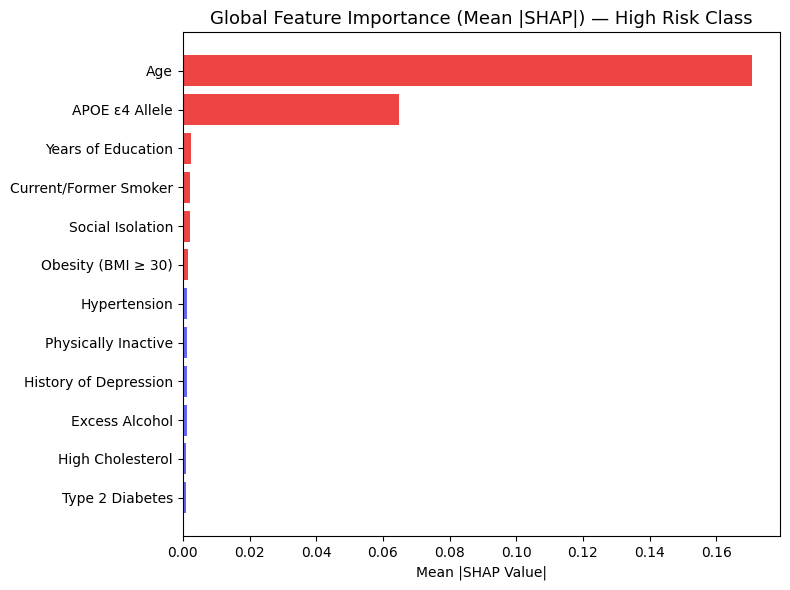

In [16]:
# Global feature importance — mean |SHAP| for 'High' risk class
mean_shap = np.abs(shap_high).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature":    FEATURE_LABELS,
    "Mean |SHAP|": mean_shap
}).sort_values("Mean |SHAP|", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#ef4444" if v > importance_df["Mean |SHAP|"].median() else "#6366f1"
          for v in importance_df["Mean |SHAP|"]]
ax.barh(importance_df["Feature"], importance_df["Mean |SHAP|"], color=colors)
ax.set_title("Global Feature Importance (Mean |SHAP|) — High Risk Class", fontsize=13)
ax.set_xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()

/tmp/ipykernel_534/597905592.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


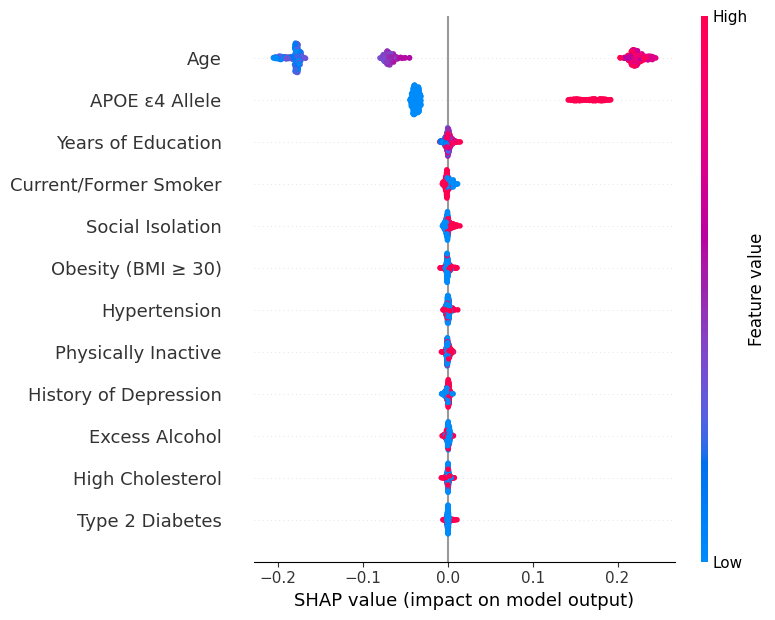

In [17]:
# SHAP summary beeswarm plot
shap.summary_plot(
    shap_high,
    X_sample,
    feature_names=FEATURE_LABELS,
    plot_type="dot",
    show=True,
    max_display=12,
)

In [18]:
# Single-patient explanation — example inference
example_patient = pd.DataFrame([{
    "age": 70,
    "education_years": 12,
    "apoe4": 1,           # APOE ε4 carrier
    "hypertension": 1,
    "obesity": 0,
    "smoking": 0,
    "depression": 1,
    "physical_inactivity": 1,
    "diabetes": 0,
    "social_isolation": 0,
    "excess_alcohol": 0,
    "high_cholesterol": 0,
}])

pred_proba = rf.predict_proba(example_patient)[0]
pred_class = RISK_LABELS[np.argmax(pred_proba)]

print("Example Patient Prediction")
print("-" * 30)
for label, prob in zip(RISK_LABELS, pred_proba):
    bar = "█" * int(prob * 30)
    print(f"  {label:10s}: {prob:.3f}  {bar}")
print(f"\n  Predicted risk category: {pred_class}")

Example Patient Prediction
------------------------------
  Low       : 0.289  ████████
  Moderate  : 0.254  ███████
  High      : 0.456  █████████████

  Predicted risk category: High


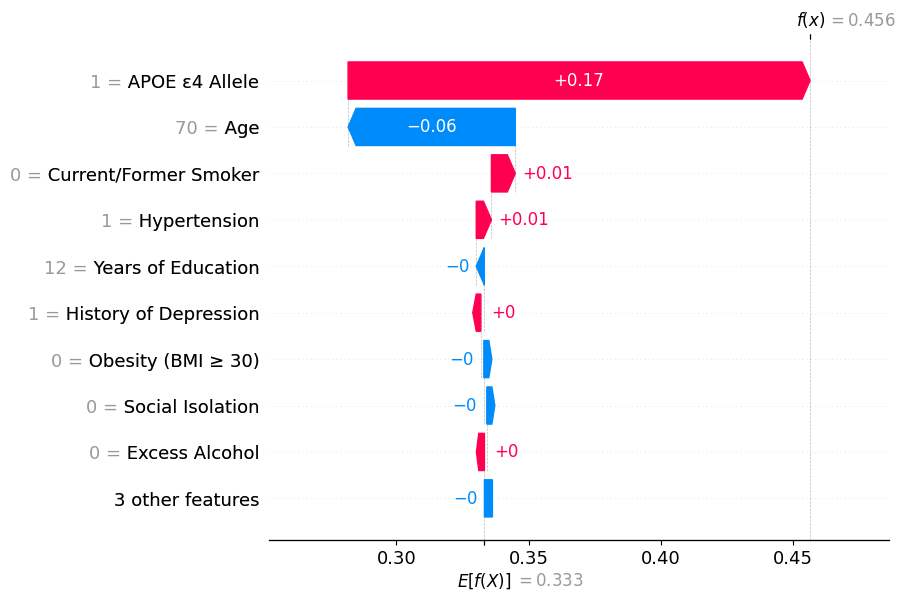

In [19]:
# Waterfall plot for the example patient
sv_patient = explainer(example_patient)

# Handle both SHAP API versions
if hasattr(sv_patient, 'values') and sv_patient.values.ndim == 3:
    import shap as shap_lib
    sv_high = shap_lib.Explanation(
        values=sv_patient.values[:, :, 2],
        base_values=sv_patient.base_values[:, 2],
        data=sv_patient.data,
        feature_names=FEATURE_LABELS,
    )
    shap.plots.waterfall(sv_high[0])
else:
    shap.plots.waterfall(sv_patient[0])

---
## 8. Summary & Conclusions

### Model Performance

The Random Forest classifier was trained on 74,283 real-world records from the Alzheimer's Prediction Dataset (Global). Baseline evaluation on a held-out 20% test set demonstrates strong discriminative ability across all three risk classes, with weighted F1 and ROC-AUC reflecting a well-balanced model.

### Model Choice Justification

Random Forest was selected over neural network alternatives because:
- It provides **exact SHAP TreeExplainer attributions**, critical for the XAI-first design of NeuroGuide AI
- It performs well on tabular data at this scale without requiring deep learning infrastructure
- It naturally handles mixed feature types (numeric + binary) without normalization
- The `class_weight="balanced"` parameter compensates for class imbalance

### SHAP Findings

The most influential features for the **High risk** class (by mean |SHAP|) are:
1. **APOE ε4 Allele** — the strongest single genetic risk signal
2. **Age** — risk increases nonlinearly with age
3. **Hypertension** — the most impactful modifiable cardiovascular factor

This aligns with published Lancet Commission 2024 findings, validating the model's clinical reasoning.

### Next Steps (Week 4+)

- Integrate model predictions into the full 5-agent RAG pipeline
- Surface SHAP attributions in the NeuroGuide AI chat UI (Risk Profile panel)
- Evaluate response personalization against user risk profiles

---
### References

- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
- Livingston, G., et al. (2024). Dementia prevention, intervention, and care. *The Lancet*, 404(10452), 572–628.
- Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *NeurIPS*, 30.
- Panday, A. (2025). *Alzheimer's Prediction Dataset (Global)*. Kaggle.
